# MyPortfolioManagement - Complete Tutorial

**Comprehensive portfolio management and optimization using Python**

This notebook demonstrates all major functions in the myPortfolioManagement library.

**Compatible with:** Kaggle, Google Colab

**Repository:** https://github.com/ferhat00/QuantitativePortfolioManagement

---

## Table of Contents

1. [Setup & Installation](#setup)
2. [Data Fetching](#section1)
3. [Returns Calculation](#section2)
4. [Utility Functions](#section3)
5. [Portfolio Optimization](#section4)
6. [Performance Metrics](#section5)
7. [Low-Level Risk Metrics](#section6)
8. [Backtesting & Simulation](#section7)
9. [Bootstrapping](#section8)
10. [Clustering & Analysis](#section9)
11. [Visualization](#section10)
12. [Portfolio Selection](#section11)
13. [Complete Workflow](#section12)

---

## <a id="setup"></a>🚀 Setup & Installation

This section will:
1. Clone the GitHub repository
2. Install dependencies (optimized to avoid conflicts)
3. Set up the environment
4. Verify installation

**⏱️ Estimated time:** 3-5 minutes

In [1]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# 1. Clone and navigate
!git clone https://github.com/msh855/QuantitativePortfolioManagement.git
%cd QuantitativePortfolioManagement
!git checkout fc_func_usage_example_update
!git pull origin fc_func_usage_example_update

Cloning into 'QuantitativePortfolioManagement'...
remote: Enumerating objects: 2115, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 2115 (delta 101), reused 94 (delta 87), pack-reused 1933 (from 1)
Receiving objects: 100% (2115/2115), 54.70 MiB | 29.02 MiB/s, done.
Resolving deltas: 100% (1370/1370), done.
/kaggle/working/QuantitativePortfolioManagement
Branch 'fc_func_usage_example_update' set up to track remote branch 'fc_func_usage_example_update' from 'origin'.
Switched to a new branch 'fc_func_usage_example_update'
From https://github.com/msh855/QuantitativePortfolioManagement
 * branch            fc_func_usage_example_update -> FETCH_HEAD
Already up to date.


In [3]:
%%writefile requirements-core.txt
pandas>=2.2.0
numpy>=2.0.0,<2.3.0
yfinance==0.2.58
quandl
finvizfinance
yahoofinancials
riskfolio-lib>=6.0.0
pyportfolioopt>=1.5.5
quantstats-lumi>=0.3.0
empyrical-reloaded>=0.5.0
ffn>=1.0.0
pyfolio-reloaded>=0.9.0
matplotlib>=3.9.0
seaborn>=0.13.0
plotly>=5.15.0
scikit-learn>=1.6.0
scipy>=1.14.0
arch>=7.0.0
tslearn>=0.7.0
tsmoothie>=1.0.4
timebudget>=0.1.0
feature-engine>=1.9.0
joblib>=1.5.0
tqdm>=4.65.0
parallel-pandas>=0.7.0

Overwriting requirements-core.txt


In [4]:
# 3. Install core packages first
!pip install --upgrade pip
!pip install -r requirements-core.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 11.0 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 26.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 72.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 55.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.4/621.4 kB 28.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 24.2 MB/s  0:00:00
  Created wheel for yahoofinancials: filename=yaho

In [5]:
# 4. Install Ray and OpenBB separately
!pip install ray==2.53.0
!pip install openbb==4.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 122.9 MB/s  0:00:00
  Attempting uninstall: ray
    Found existing installation: ray 2.52.1
    Uninstalling ray-2.52.1:
      Successfully uninstalled ray-2.52.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 78.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 141.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 35.4 MB/s  0:00:00
  Attempting uninstall: uvicorn
    Found existing installation: uvicorn 0.38.0
    Uninstalling uvicorn-0.38.0:
      Successfully uninstalled uvicorn-0.38.0
  Attempting uninstall: ruff
    Found existing installation: ruff 0.14.1
    Uninstalling ruff-0.14.1:
      Successfully uninstalled ruff-0.14.1
  Attempting uninstall: aiosqlite
    Found existing installation: aiosqlite 0.22.0
    Uninstalling aiosqlite-0.22.0:
      Successfully uninstalled aiosqlite-0.22.0
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2

In [6]:
# 5. Install the package
!pip install -e .

Obtaining file:///kaggle/working/QuantitativePortfolioManagement
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 12.0 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Building editable for myPortfolioManagement (pyproject.toml) ... done
  Created wheel for myPortfolioManagement: filename=myportfoliomanagement-1.0-0.editable-py3-none-any.whl size=15691 sha256=a2b8f8c611bfc8b6220c39781c179856f8caefee8193713ad06621b889ad8fe7
  Stored in directory: /tmp/pip-ephem-wheel-cache-j9mkztrb/wheels/30/bd/d1/1723515285f61dca484ff16c26e08b96fdf9f292b91d815f54
  Created wheel for investpy: filename=investpy-1.0.8-py3-none-any.whl size=4481672 sha256=c9c43ca039f0209978c744c20a8cda8e5953a1

In [7]:
# Verify installation and import all necessary libraries
import warnings
warnings.filterwarnings('ignore')

print("🔍 Verifying installation...\n")

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("✅ Core libraries (pandas, numpy, matplotlib, seaborn)")
except ImportError as e:
    print(f"❌ Core libraries error: {e}")

try:
    import yfinance as yf
    import riskfolio as rp
    import quantstats_lumi as qs
    from pypfopt import EfficientFrontier
    import ffn
    print("✅ Financial libraries (yfinance, riskfolio, quantstats, pypfopt, ffn)")
except ImportError as e:
    print(f"❌ Financial libraries error: {e}")

try:
    from myPortfolioManagement.myData import get_stock_prices
    from myPortfolioManagement.myReturns import calculate_returns
    from myPortfolioManagement.myPortfolioOptimisation import HRP
    from myPortfolioManagement.myPerformanceMetrics import get_main_stats
    print("✅ myPortfolioManagement package")
except ImportError as e:
    print(f"❌ Package import error: {e}")

# Configure pandas display
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

# Configure matplotlib
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("\n" + "="*80)
print("🎉 SETUP COMPLETE - Ready to start!")
print("="*80)

🔍 Verifying installation...

✅ Core libraries (pandas, numpy, matplotlib, seaborn)
✅ Financial libraries (yfinance, riskfolio, quantstats, pypfopt, ffn)
Extensions to add: benzinga@1.5.1, bls@1.2.1, cftc@1.2.1, commodity@1.4.1, congress_gov@1.1.1, crypto@1.5.1, currency@1.5.1, derivatives@1.5.1, econdb@1.4.1, economy@1.5.1, equity@1.5.1, etf@1.5.1, federal_reserve@1.5.1, fixedincome@1.5.1, fmp@1.5.2, fred@1.5.1, imf@1.2.0, index@1.5.1, intrinio@1.5.1, news@1.5.1, oecd@1.5.1, polygon@1.5.1, regulators@1.5.1, sec@1.5.1, tiingo@1.5.1, tradingeconomics@1.5.1, us_eia@1.2.1, uscongress@1.1.1, yfinance@1.5.2

Building...
✅ myPortfolioManagement package

🎉 SETUP COMPLETE - Ready to start!


---
## <a id="section1"></a>📊 Section 1: Data Fetching (myData.py)

Fetch historical price data for a diversified portfolio of ETFs.

In [8]:
from myPortfolioManagement.myData import (
    get_stock_prices,
    get_stock_info,
    get_option_exp_dates
)

# Define a diversified portfolio of ETFs
tickers = [
    'SPY',   # S&P 500
    'QQQ',   # Nasdaq 100
    'IWM',   # Russell 2000 (Small Cap)
    'EFA',   # International Developed
    'EEM',   # Emerging Markets
    'AGG',   # US Bonds
    'TIP',   # TIPS (Inflation Protected)
    'GLD',   # Gold
    'VNQ',   # Real Estate
    'DBC',   # Commodities
]

print("="*80)
print("SECTION 1: DATA FETCHING")
print("="*80)

print("\n1.1 📥 Fetching stock prices...")
print(f"Tickers: {', '.join(tickers)}")

# Fetch historical prices
prices = get_stock_prices(
    yahoo_tickers=tickers,
    start_date='2018-01-01',
    end_date='2024-12-01',
    freq='daily',
    wide_format=True
)

print(f"\n✅ Success!")
print(f"   Price data shape: {prices.shape}")
print(f"   Date range: {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"   Trading days: {len(prices)}")
print("\n📋 First 5 rows:")
display(prices.head())

SECTION 1: DATA FETCHING

1.1 📥 Fetching stock prices...
Tickers: SPY, QQQ, IWM, EFA, EEM, AGG, TIP, GLD, VNQ, DBC


100%|██████████| 10/10 [00:01<00:00,  5.90it/s]


get_stock_prices took 3.743sec

✅ Success!
   Price data shape: (1740, 10)
   Date range: 2018-01-02 to 2024-11-29
   Trading days: 1740

📋 First 5 rows:


longname,Invesco DB Commodity Index Tracking Fund,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,,
2018-01-02,14.1104,150.4116,125.1500,237.2082,60.8142,86.9814,55.6033,39.9833,139.1315,88.6665
2018-01-03,14.1949,151.8730,124.8200,238.7086,60.6377,86.9893,55.8702,40.3664,139.2761,88.7523
2018-01-04,14.1780,152.1388,125.4600,239.7147,59.5931,86.9336,56.4825,40.5663,139.6468,88.7756
2018-01-05,14.1273,153.6667,125.3300,241.3121,59.6225,86.8778,56.7966,40.9160,139.9361,88.7600
2018-01-08,14.1188,154.2646,125.3100,241.7535,59.9314,86.8539,56.7808,40.9160,140.1530,88.6665


In [9]:
print("1.2 ℹ️ Fetching stock information...")
stock_info = get_stock_info(tickers)
print("\n📋 Stock Information:")
display(stock_info[['yahooTicker', 'longName', 'type', 'currency', 'sector']])

1.2 ℹ️ Fetching stock information...


100%|██████████| 10/10 [00:01<00:00,  6.51it/s]



📋 Stock Information:


,yahooTicker,longName,type,currency,sector
0,SPY,SPDR S&P 500 ETF,ETF,USD,Other
1,QQQ,Invesco QQQ Trust,ETF,USD,Other
2,IWM,iShares Russell 2000 ETF,ETF,USD,Other
3,EFA,iShares MSCI EAFE ETF,ETF,USD,Other
4,EEM,iShares MSCI Emerging Markets ETF,ETF,USD,Other
5,AGG,iShares Core U.S. Aggregate Bond ETF,ETF,USD,Other
6,TIP,iShares TIPS Bond ETF,ETF,USD,Other
7,GLD,SPDR Gold Shares,ETF,USD,Other
8,VNQ,Vanguard Real Estate Index Fund ETF Shares,ETF,USD,Other
9,DBC,Invesco DB Commodity Index Tracking Fund,ETF,USD,Other


1.3 📈 Visualizing normalized prices...


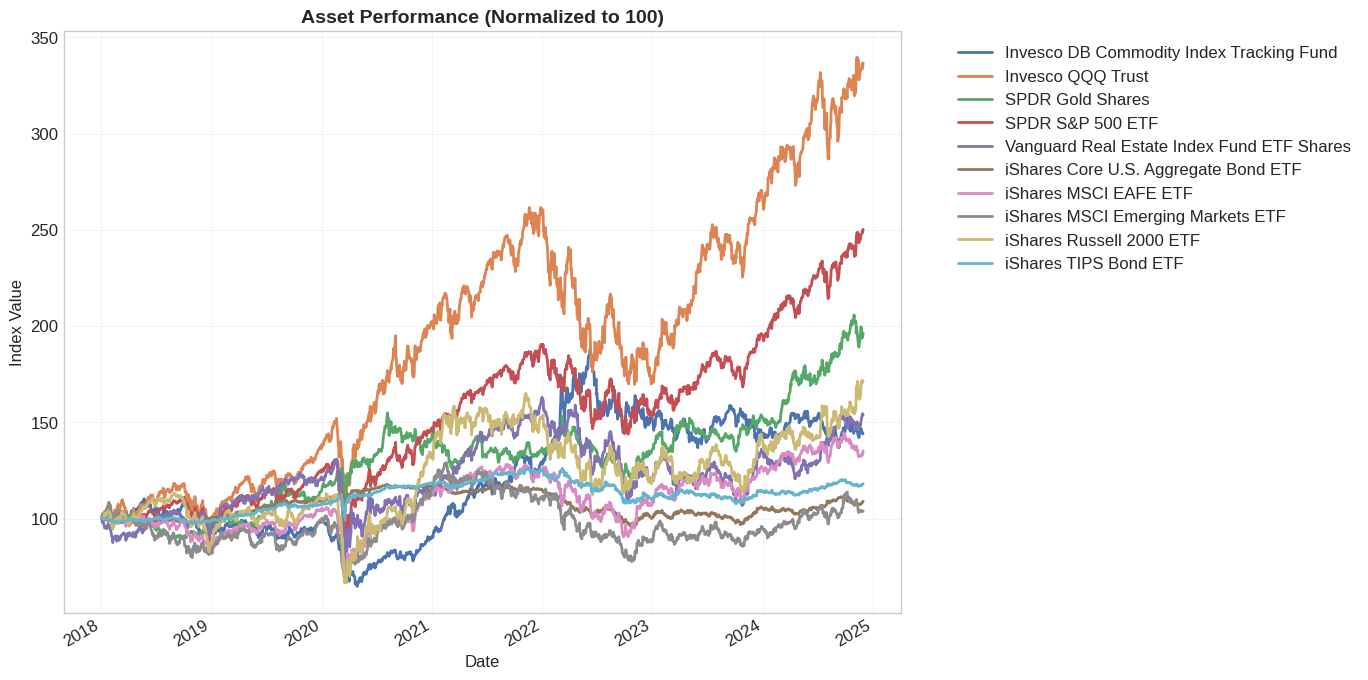


✅ Data fetching complete!


In [10]:
print("1.3 📈 Visualizing normalized prices...")

# Normalize prices to 100
normalized = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 7))
normalized.plot(ax=ax, linewidth=2)
ax.set_title('Asset Performance (Normalized to 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Index Value', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Data fetching complete!")

---
## <a id="section2"></a>📈 Section 2: Returns Calculation (myReturns.py)

Calculate and analyze returns using different methods and frequencies.

In [11]:
from myPortfolioManagement.myReturns import (
    calculate_returns,
    average_returns,
    convert_returns_freq,
    calculate_portfolio_returns
)

print("="*80)
print("SECTION 2: RETURNS CALCULATION")
print("="*80)

SECTION 2: RETURNS CALCULATION


In [12]:
print("\n2.1 📊 Calculating daily returns...")
returns_daily = calculate_returns(prices, log_returns=False)
print(f"✅ Daily returns shape: {returns_daily.shape}")
print("\n📋 Daily returns (first 5 rows):")
display(returns_daily.head())


2.1 📊 Calculating daily returns...
✅ Daily returns shape: (1739, 10)

📋 Daily returns (first 5 rows):


longname,Invesco DB Commodity Index Tracking Fund,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,,
2018-01-03,0.0060,0.0097,-0.0026,0.0063,-0.0029,0.0001,0.0048,0.0096,0.0010,0.0010
2018-01-04,-0.0012,0.0017,0.0051,0.0042,-0.0172,-0.0006,0.0110,0.0050,0.0027,0.0003
2018-01-05,-0.0036,0.0100,-0.0010,0.0067,0.0005,-0.0006,0.0056,0.0086,0.0021,-0.0002
2018-01-08,-0.0006,0.0039,-0.0002,0.0018,0.0052,-0.0003,-0.0003,0.0000,0.0016,-0.0011
2018-01-09,0.0066,0.0001,-0.0046,0.0023,-0.0129,-0.0028,0.0011,-0.0016,-0.0014,-0.0033


In [13]:
print("2.2 📊 Calculating log returns...")
returns_log = calculate_returns(prices, log_returns=True)
print("\n📋 Log returns statistics:")
display(returns_log.describe().T[['mean', 'std', 'min', 'max']])

2.2 📊 Calculating log returns...

📋 Log returns statistics:


,mean,std,min,max
longname,,,,
Invesco DB Commodity Index Tracking Fund,0.0002,0.0117,-0.0828,0.0469
Invesco QQQ Trust,0.0007,0.0153,-0.1276,0.0813
SPDR Gold Shares,0.0004,0.0090,-0.0552,0.0474
SPDR S&P 500 ETF,0.0005,0.0123,-0.1159,0.0867
Vanguard Real Estate Index Fund ETF Shares,0.0002,0.0146,-0.1951,0.0861
iShares Core U.S. Aggregate Bond ETF,0.0000,0.0038,-0.0408,0.0234
iShares MSCI EAFE ETF,0.0002,0.0116,-0.1164,0.0813
iShares MSCI Emerging Markets ETF,0.0000,0.0136,-0.1333,0.0775
iShares Russell 2000 ETF,0.0003,0.0158,-0.1423,0.0875


In [14]:
print("2.3 📅 Converting to monthly returns...")
returns_monthly = calculate_returns(prices, convert_to='monthly')
print(f"✅ Monthly returns shape: {returns_monthly.shape}")
print("\n📋 Monthly returns (last 12 months):")
display(returns_monthly.tail(12))

2.3 📅 Converting to monthly returns...
✅ Monthly returns shape: (83, 10)

📋 Monthly returns (last 12 months):


longname,Invesco DB Commodity Index Tracking Fund,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,,
2023-12-31,-0.0329,0.0559,0.0128,0.0457,0.0945,0.0370,0.0535,0.0357,0.1213,0.0244
2024-01-31,0.0132,0.0182,-0.0142,0.0159,-0.0506,-0.0015,-0.0045,-0.0453,-0.0390,0.0033
2024-02-29,-0.0152,0.0528,0.0046,0.0522,0.0198,-0.0147,0.0299,0.0417,0.0563,-0.0105
2024-03-31,0.0446,0.0127,0.0867,0.0327,0.0195,0.0090,0.0338,0.0273,0.0349,0.0065
2024-04-30,0.0161,-0.0437,0.0299,-0.0403,-0.0794,-0.0248,-0.0324,-0.0022,-0.0685,-0.0169
2024-05-31,-0.0030,0.0615,0.0162,0.0506,0.0456,0.0167,0.0506,0.0195,0.0504,0.0178
2024-06-30,-0.0017,0.0647,-0.0013,0.0353,0.0188,0.0089,-0.0183,0.0262,-0.0112,0.0076
2024-07-31,-0.0280,-0.0168,0.0537,0.0121,0.0794,0.0242,0.0259,0.0085,0.1034,0.0173
2024-08-31,-0.0208,0.0110,0.0209,0.0234,0.0522,0.0146,0.0326,0.0098,-0.0169,0.0080


In [15]:
print("2.4 💰 Calculating expected returns (different methods)...")

# Historical mean
mu_hist = average_returns(returns_daily, method='hist', periods=252)
print("\n📊 Expected Returns (Historical Mean):")
display(mu_hist.sort_values(ascending=False))

# Exponential Moving Average
mu_ema = average_returns(returns_daily, method='ema', span=500, periods=252)
print("\n📊 Expected Returns (EMA):")
display(mu_ema.sort_values(ascending=False))

2.4 💰 Calculating expected returns (different methods)...

📊 Expected Returns (Historical Mean):


longname
Invesco QQQ Trust                            0.1923
SPDR S&P 500 ETF                             0.1421
SPDR Gold Shares                             0.1026
iShares Russell 2000 ETF                     0.0812
Vanguard Real Estate Index Fund ETF Shares   0.0644
Invesco DB Commodity Index Tracking Fund     0.0544
iShares MSCI EAFE ETF                        0.0448
iShares TIPS Bond ETF                        0.0244
iShares Core U.S. Aggregate Bond ETF         0.0125
iShares MSCI Emerging Markets ETF            0.0055
dtype: float64


📊 Expected Returns (EMA):


longname
Invesco QQQ Trust                            0.2855
SPDR S&P 500 ETF                             0.2618
iShares Russell 2000 ETF                     0.2541
SPDR Gold Shares                             0.2285
Vanguard Real Estate Index Fund ETF Shares   0.1798
iShares MSCI EAFE ETF                        0.0833
iShares MSCI Emerging Markets ETF            0.0685
iShares Core U.S. Aggregate Bond ETF         0.0358
iShares TIPS Bond ETF                        0.0303
Invesco DB Commodity Index Tracking Fund     0.0026
Name: 2024-11-29 00:00:00, dtype: float64

In [16]:
print("2.5 📊 Getting benchmark returns (S&P 500)...")

# Helper function to fix benchmark returns (handles quantstats compatibility)
def get_benchmark_returns_fixed(ticker='^GSPC', name='S&P500'):
    ret_data = qs.utils.download_returns(ticker)
    if isinstance(ret_data, pd.DataFrame):
        ret = ret_data.squeeze()
    else:
        ret = ret_data
    ret.name = name
    return pd.DataFrame(ret)

benchmark_sp500 = get_benchmark_returns_fixed('^GSPC', 'S&P500')
print(f"\n✅ S&P 500 benchmark shape: {benchmark_sp500.shape}")
display(benchmark_sp500.tail())

print("\n✅ Returns calculation complete!")

2.5 📊 Getting benchmark returns (S&P 500)...


[*********************100%***********************]  1 of 1 completed


✅ S&P 500 benchmark shape: (24616, 1)


,S&P500
Date,
2025-12-23,0.0046
2025-12-24,0.0032
2025-12-26,-0.0003
2025-12-29,-0.0035
2025-12-30,-0.0014



✅ Returns calculation complete!


---
## <a id="section3"></a>🔧 Section 3: Utility Functions (myUtils.py)

Demonstrate utility functions for data manipulation and quality checks.

In [17]:
from myPortfolioManagement.myUtils import (
    data_overview,
    balance_dates,
    check_date_index,
    cap_outliersTS
)

print("="*80)
print("SECTION 3: UTILITY FUNCTIONS")
print("="*80)

SECTION 3: UTILITY FUNCTIONS


In [18]:
print("\n3.1 🔍 Data overview (checking data quality)...")
# Convert to long format for data_overview
prices_long = prices.reset_index().melt(
    id_vars='Date', 
    var_name='asset', 
    value_name='price'
)

overview = data_overview(
    prices_long,
    my_assets_col_name='asset',
    my_date_col_name='Date',
    price_col_name='price'
)
print("\n📋 Data Overview:")
display(overview)


3.1 🔍 Data overview (checking data quality)...

📋 Data Overview:


,Date_min,Date_max,trading_days,years_available,percentage_of_NAs
asset,,,,,
Invesco DB Commodity Index Tracking Fund,2018-01-02,2024-11-29,2523,6.9123,0.0000
Invesco QQQ Trust,2018-01-02,2024-11-29,2523,6.9123,0.0000
SPDR Gold Shares,2018-01-02,2024-11-29,2523,6.9123,0.0000
SPDR S&P 500 ETF,2018-01-02,2024-11-29,2523,6.9123,0.0000
Vanguard Real Estate Index Fund ETF Shares,2018-01-02,2024-11-29,2523,6.9123,0.0000
iShares Core U.S. Aggregate Bond ETF,2018-01-02,2024-11-29,2523,6.9123,0.0000
iShares MSCI EAFE ETF,2018-01-02,2024-11-29,2523,6.9123,0.0000
iShares MSCI Emerging Markets ETF,2018-01-02,2024-11-29,2523,6.9123,0.0000
iShares Russell 2000 ETF,2018-01-02,2024-11-29,2523,6.9123,0.0000


In [19]:
print("3.2 ⚖️ Balancing dates between returns and benchmark...")
returns_balanced, benchmark_balanced = balance_dates(returns_daily, benchmark_sp500)
print(f"✅ Balanced returns shape: {returns_balanced.shape}")
print(f"✅ Balanced benchmark shape: {benchmark_balanced.shape}")

3.2 ⚖️ Balancing dates between returns and benchmark...
✅ Balanced returns shape: (2009, 10)
✅ Balanced benchmark shape: (2009, 1)


In [20]:
print("3.3 ✂️ Capping outliers in time series...")
try:
    prices_capped = cap_outliersTS(
        returns_daily, 
        capping_method='iqr', 
        fold=3, 
        plot=False
    )
    print(f"✅ Capped prices shape: {prices_capped.shape}")
except Exception as e:
    print(f"⚠️ Outlier capping: {e}")

print("\n✅ Utility functions complete!")

3.3 ✂️ Capping outliers in time series...
✅ Capped prices shape: (1677, 10)

✅ Utility functions complete!


---
## <a id="section4"></a>🎯 Section 4: Portfolio Optimization (myPortfolioOptimisation.py)

Generate optimal portfolio weights using various optimization methods.

In [21]:
from myPortfolioManagement.myPortfolioOptimisation import (
    HRP,
    equal_weight_portfolio,
    inverse_vol_portfolio,
    port_GMV,
    port_max_sharpe,
    port_target_return,
    port_target_volatility,
    port_CVAR,
    generate_rp_portfolios,
    risk_contributions
)

print("="*80)
print("SECTION 4: PORTFOLIO OPTIMIZATION")
print("="*80)

# Use returns for optimization (fill NaN with 0)
returns_opt = returns_daily.fillna(0)

SECTION 4: PORTFOLIO OPTIMIZATION


In [22]:
print("\n4.1 ⚖️ Equal Weight Portfolio...")
weights_equal = equal_weight_portfolio(returns_opt)
print("\n📊 Equal Weight Portfolio:")
display(weights_equal)


4.1 ⚖️ Equal Weight Portfolio...

📊 Equal Weight Portfolio:


,port_naive
asset,
Invesco DB Commodity Index Tracking Fund,0.1000
Invesco QQQ Trust,0.1000
SPDR Gold Shares,0.1000
SPDR S&P 500 ETF,0.1000
Vanguard Real Estate Index Fund ETF Shares,0.1000
iShares Core U.S. Aggregate Bond ETF,0.1000
iShares MSCI EAFE ETF,0.1000
iShares MSCI Emerging Markets ETF,0.1000
iShares Russell 2000 ETF,0.1000


In [23]:
print("4.2 📉 Inverse Volatility Portfolio...")
weights_inv_vol = inverse_vol_portfolio(returns_opt, weight_max=0.25)
print("\n📊 Inverse Volatility Portfolio:")
display(weights_inv_vol.sort_values('port_inverse_vol', ascending=False))

4.2 📉 Inverse Volatility Portfolio...

📊 Inverse Volatility Portfolio:


,port_inverse_vol
asset,
iShares Core U.S. Aggregate Bond ETF,0.2299
iShares TIPS Bond ETF,0.2165
SPDR Gold Shares,0.0962
iShares MSCI EAFE ETF,0.0756
Invesco DB Commodity Index Tracking Fund,0.0743
SPDR S&P 500 ETF,0.0706
iShares MSCI Emerging Markets ETF,0.0643
Vanguard Real Estate Index Fund ETF Shares,0.0601
Invesco QQQ Trust,0.0570


In [24]:
print("4.3 🌳 Hierarchical Risk Parity (HRP)...")
weights_hrp = HRP(
    model='HRP',
    returns_training=returns_opt,
    codependence='pearson',
    covariance='ledoit',
    rm='MV',
    linkage='ward',
    weight_max=0.25,
    weight_min=0.02
)
print("\n📊 HRP Portfolio:")
display(weights_hrp.sort_values('port_weight', ascending=False))

4.3 🌳 Hierarchical Risk Parity (HRP)...

📊 HRP Portfolio:


,port_weight
asset,
iShares TIPS Bond ETF,0.2500
iShares Core U.S. Aggregate Bond ETF,0.2500
SPDR Gold Shares,0.1406
SPDR S&P 500 ETF,0.1202
Invesco DB Commodity Index Tracking Fund,0.0846
iShares MSCI EAFE ETF,0.0746
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI Emerging Markets ETF,0.0200


In [25]:
print("4.4 🌲 HERC (Hierarchical Equal Risk Contribution)...")
weights_herc = HRP(
    model='HERC',
    returns_training=returns_opt,
    codependence='pearson',
    rm='CVaR',
    weight_max=0.30,
    weight_min=0.02
)
print("\n📊 HERC Portfolio:")
display(weights_herc.sort_values('port_weight', ascending=False))

4.4 🌲 HERC (Hierarchical Equal Risk Contribution)...

📊 HERC Portfolio:


,port_weight
asset,
iShares TIPS Bond ETF,0.3000
iShares Core U.S. Aggregate Bond ETF,0.3000
SPDR Gold Shares,0.1938
Invesco DB Commodity Index Tracking Fund,0.0862
Invesco QQQ Trust,0.0200
SPDR S&P 500 ETF,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200


In [26]:
print("4.5 📉 Global Minimum Variance Portfolio...")
weights_gmv = port_GMV(
    returns_training=returns_opt,
    weight_min=0.02,
    weight_max=0.30
)
print("\n📊 Global Minimum Variance Portfolio:")
display(weights_gmv.sort_values('port_min_vol', ascending=False))

4.5 📉 Global Minimum Variance Portfolio...

📊 Global Minimum Variance Portfolio:


,port_min_vol
asset,
iShares TIPS Bond ETF,0.3000
iShares Core U.S. Aggregate Bond ETF,0.3000
SPDR Gold Shares,0.1770
Invesco DB Commodity Index Tracking Fund,0.0994
SPDR S&P 500 ETF,0.0236
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200


In [27]:
print("4.6 📈 Maximum Sharpe Ratio Portfolio...")
weights_max_sharpe = port_max_sharpe(
    returns_training=returns_opt,
    rf=0.04,
    weight_min=0.02,
    weight_max=0.30
)
print("\n📊 Max Sharpe Portfolio:")
display(weights_max_sharpe.sort_values('port_max_Sharpe', ascending=False))

4.6 📈 Maximum Sharpe Ratio Portfolio...

📊 Max Sharpe Portfolio:


,port_max_Sharpe
asset,
SPDR Gold Shares,0.3000
Invesco QQQ Trust,0.2944
iShares TIPS Bond ETF,0.2656
Invesco DB Commodity Index Tracking Fund,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
SPDR S&P 500 ETF,0.0200
iShares Core U.S. Aggregate Bond ETF,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200


In [28]:
print("4.7 🛡️ Minimum CVaR Portfolio...")
weights_cvar = port_CVAR(
    returns_training=returns_opt,
    confidence_interval=0.95,
    rf=0.04,
    weight_min=0.02,
    weight_max=0.30
)
print("\n📊 Minimum CVaR Portfolio:")
display(weights_cvar.sort_values('port_target_CVAR', ascending=False))

4.7 🛡️ Minimum CVaR Portfolio...

📊 Minimum CVaR Portfolio:


,port_target_CVAR
asset,
iShares TIPS Bond ETF,0.3000
iShares Core U.S. Aggregate Bond ETF,0.3000
SPDR Gold Shares,0.1811
Invesco DB Commodity Index Tracking Fund,0.0893
SPDR S&P 500 ETF,0.0296
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200


In [29]:
# Compare all portfolios
# First, let's inspect the structure of each weights dataframe
print("Inspecting weight dataframes...")
print("\nweights_equal columns:", weights_equal.columns.tolist())
print("weights_inv_vol columns:", weights_inv_vol.columns.tolist())
print("weights_hrp columns:", weights_hrp.columns.tolist())
print("weights_herc columns:", weights_herc.columns.tolist())
print("weights_gmv columns:", weights_gmv.columns.tolist())
print("weights_max_sharpe columns:", weights_max_sharpe.columns.tolist())
print("weights_cvar columns:", weights_cvar.columns.tolist())

# Now build the comparison dataframe more robustly
all_weights = pd.DataFrame(index=weights_hrp.index)

# Extract weights, handling different column names
all_weights['Equal'] = weights_equal['port_naive'].values if 'port_naive' in weights_equal.columns else weights_equal.iloc[:, -1].values
all_weights['Inv_Vol'] = weights_inv_vol['port_inverse_vol'].values if 'port_inverse_vol' in weights_inv_vol.columns else weights_inv_vol.iloc[:, -1].values
all_weights['HRP'] = weights_hrp['port_weight'].values if 'port_weight' in weights_hrp.columns else weights_hrp.iloc[:, -1].values
all_weights['HERC'] = weights_herc['port_weight'].values if 'port_weight' in weights_herc.columns else weights_herc.iloc[:, -1].values

# For GMV, Max_Sharpe, and CVaR - handle cases where 'asset' might be index or column
if 'asset' in weights_gmv.columns:
    all_weights['GMV'] = weights_gmv.set_index('asset')['port_min_vol']
else:
    all_weights['GMV'] = weights_gmv['port_min_vol'].values if 'port_min_vol' in weights_gmv.columns else weights_gmv.iloc[:, -1].values

if 'asset' in weights_max_sharpe.columns:
    all_weights['Max_Sharpe'] = weights_max_sharpe.set_index('asset')['port_max_Sharpe']
else:
    all_weights['Max_Sharpe'] = weights_max_sharpe['port_max_Sharpe'].values if 'port_max_Sharpe' in weights_max_sharpe.columns else weights_max_sharpe.iloc[:, -1].values

if 'asset' in weights_cvar.columns:
    all_weights['Min_CVaR'] = weights_cvar.set_index('asset')['port_target_CVAR']
else:
    all_weights['Min_CVaR'] = weights_cvar['port_target_CVAR'].values if 'port_target_CVAR' in weights_cvar.columns else weights_cvar.iloc[:, -1].values

print("\nAll Portfolio Weights Comparison:")
all_weights.round(3)

Inspecting weight dataframes...

weights_equal columns: ['port_naive']
weights_inv_vol columns: ['port_inverse_vol']
weights_hrp columns: ['port_weight']
weights_herc columns: ['port_weight']
weights_gmv columns: ['port_min_vol']
weights_max_sharpe columns: ['port_max_Sharpe']
weights_cvar columns: ['port_target_CVAR']

All Portfolio Weights Comparison:


,Equal,Inv_Vol,HRP,HERC,GMV,Max_Sharpe,Min_CVaR
asset,,,,,,,
Invesco DB Commodity Index Tracking Fund,0.1000,0.0740,0.0850,0.0860,0.0990,0.0200,0.0890
Invesco QQQ Trust,0.1000,0.0570,0.0200,0.0200,0.0200,0.2940,0.0200
SPDR Gold Shares,0.1000,0.0960,0.1410,0.1940,0.1770,0.3000,0.1810
SPDR S&P 500 ETF,0.1000,0.0710,0.1200,0.0200,0.0240,0.0200,0.0300
Vanguard Real Estate Index Fund ETF Shares,0.1000,0.0600,0.0200,0.0200,0.0200,0.0200,0.0200
iShares Core U.S. Aggregate Bond ETF,0.1000,0.2300,0.2500,0.3000,0.3000,0.0200,0.3000
iShares MSCI EAFE ETF,0.1000,0.0760,0.0750,0.0200,0.0200,0.0200,0.0200
iShares MSCI Emerging Markets ETF,0.1000,0.0640,0.0200,0.0200,0.0200,0.0200,0.0200
iShares Russell 2000 ETF,0.1000,0.0550,0.0200,0.0200,0.0200,0.0200,0.0200


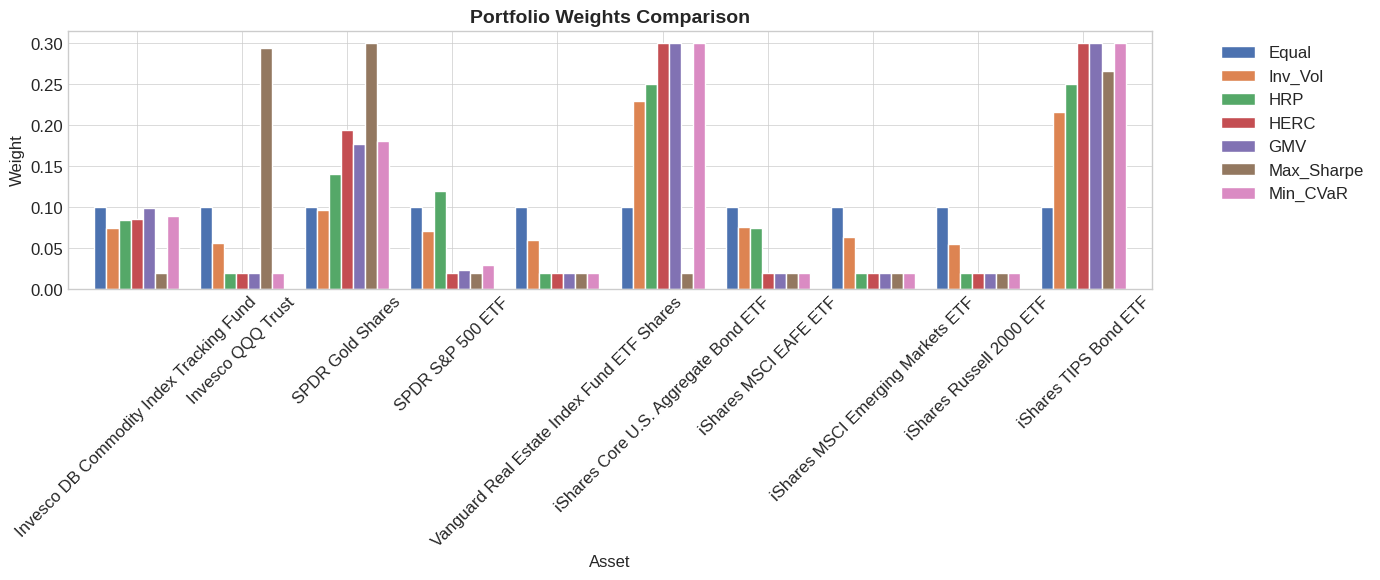


✅ Portfolio optimization complete!


In [30]:
# Visualize
fig, ax = plt.subplots(figsize=(14, 6))
all_weights.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Portfolio Weights Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Asset', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✅ Portfolio optimization complete!")

---
## <a id="section5"></a>📊 Section 5: Performance Metrics (myPerformanceMetrics.py)

Calculate comprehensive risk and return metrics.

In [31]:
from myPortfolioManagement.myPerformanceMetrics import (
    get_main_stats,
    alpha_beta_table,
    alpha_beta_bull,
    alpha_beta_bear,
    information_ratio,
    drawdown_details,
    assets_drawdown_details,
    performance_overview,
    cagr,
    beta_Co_Moments_table
)

print("="*80)
print("SECTION 5: PERFORMANCE METRICS")
print("="*80)

SECTION 5: PERFORMANCE METRICS


In [32]:
print("\n5.1 📊 Main Performance Statistics...")
main_stats = get_main_stats(returns_daily, rf=0.04, smart=True)
print("\n📋 Main Performance Stats:")
display(main_stats.round(4))


5.1 📊 Main Performance Statistics...
get_main_stats took 244.36ms

📋 Main Performance Stats:


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
Invesco DB Commodity Index Tracking Fund,0.4410,0.0543,0.2544,0.2689,0.1303,-0.4171
Invesco QQQ Trust,2.3664,0.1922,0.8453,0.8517,0.5473,-0.3512
SPDR Gold Shares,0.9624,0.1026,0.6540,0.6525,0.4661,-0.2200
SPDR S&P 500 ETF,1.5023,0.1421,0.7253,0.7400,0.4213,-0.3372
Vanguard Real Estate Index Fund ETF Shares,0.5381,0.0643,0.3003,0.3121,0.1518,-0.4240
iShares Core U.S. Aggregate Bond ETF,0.0897,0.0125,-0.2351,-0.2472,0.0679,-0.1843
iShares MSCI EAFE ETF,0.3528,0.0447,0.2036,0.2119,0.1308,-0.3419
iShares MSCI Emerging Markets ETF,0.0389,0.0055,0.0080,0.0083,0.0139,-0.3982
iShares Russell 2000 ETF,0.7140,0.0812,0.3746,0.3815,0.1973,-0.4113
iShares TIPS Bond ETF,0.1813,0.0244,-0.0167,-0.0165,0.1683,-0.1451


In [33]:
print("5.2 📈 CAGR Calculation...")
cagr_values = cagr(prices)
print("\n📋 Compound Annual Growth Rate:")
display(cagr_values.sort_values(ascending=False).round(4))

5.2 📈 CAGR Calculation...

📋 Compound Annual Growth Rate:


Invesco QQQ Trust                            0.1921
SPDR S&P 500 ETF                             0.1420
SPDR Gold Shares                             0.1025
iShares Russell 2000 ETF                     0.0811
Vanguard Real Estate Index Fund ETF Shares   0.0643
Invesco DB Commodity Index Tracking Fund     0.0543
iShares MSCI EAFE ETF                        0.0447
iShares TIPS Bond ETF                        0.0244
iShares Core U.S. Aggregate Bond ETF         0.0125
iShares MSCI Emerging Markets ETF            0.0055
dtype: float64

In [34]:
print("5.3 🎯 Alpha-Beta Analysis (Full Market)...")
ab_table = alpha_beta_table(
    returns=returns_daily,
    returns_benchmark=benchmark_sp500,
    rf=0.04
)
print("\n📋 Alpha-Beta Table:")
display(ab_table)

5.3 🎯 Alpha-Beta Analysis (Full Market)...

📋 Alpha-Beta Table:


,alpha,alpha_bull,alpha_bear,beta,beta_bull,beta_bear
asset,,,,,,
Invesco DB Commodity Index Tracking Fund,-1.0000,-0.9800,-0.9300,0.2900,0.1900,0.4100
Invesco QQQ Trust,0.0800,-0.0100,-0.3200,1.0000,0.9400,0.9600
SPDR Gold Shares,-1.0000,-0.9900,-0.9900,0.0700,0.0700,0.0600
SPDR S&P 500 ETF,-0.7300,-0.5100,-0.4200,0.8700,0.8400,0.8900
Vanguard Real Estate Index Fund ETF Shares,-0.9000,-0.7300,-0.1600,0.7800,0.7700,0.8900
iShares Core U.S. Aggregate Bond ETF,-1.0000,-0.9900,-0.9900,0.0400,0.0400,0.0300
iShares MSCI EAFE ETF,-0.9500,-0.8100,-0.7200,0.7000,0.6700,0.7400
iShares MSCI Emerging Markets ETF,-0.9400,-0.8000,-0.7300,0.7300,0.6600,0.7600
iShares Russell 2000 ETF,-0.3500,-0.3500,-0.1500,0.9600,0.8800,0.9800


In [35]:
print("5.4 📉 Drawdown Details (for SPY)...")
spy_prices = prices.iloc[:, 0]
dd_details = drawdown_details(spy_prices, top_drawdowns=5)
print(f"\n📋 Top 5 Drawdowns for {prices.columns[0]}:")
display(dd_details)

print("\n✅ Performance metrics complete!")

5.4 📉 Drawdown Details (for SPY)...

📋 Top 5 Drawdowns for Invesco DB Commodity Index Tracking Fund:


,start,valley,end,days,Years,max drawdown,Peak Price,Bottom Price
11,2018-10-04,2020-04-27,2021-04-28,938,3,-42.0000,16.0000,9.0000
34,2022-06-10,2023-05-31,2024-11-29,904,2,-27.0000,26.0000,19.0000
29,2022-03-09,2022-03-16,2022-04-13,36,0,-13.0000,22.0000,21.0000
23,2021-10-21,2021-12-01,2022-01-14,86,0,-12.0000,19.0000,17.0000
10,2018-05-24,2018-08-15,2018-10-02,132,0,-10.0000,15.0000,14.0000



✅ Performance metrics complete!


---
## <a id="section6"></a>🔬 Section 6: Low-Level Risk Metrics (metrics.py)

Calculate individual risk metrics using low-level functions.

In [36]:
from myPortfolioManagement.metrics import (
    vol, beta, var, cvar, lpm, hpm,
    max_dd, dd, sharpe_ratio, sortino_ratio,
    treynor_ratio, calmar_ratio, omega_ratio,
    gain_loss_ratio, upside_potential_ratio
)

print("="*80)
print("SECTION 6: LOW-LEVEL RISK METRICS")
print("="*80)

# Use SPY returns for demonstration
spy_returns = returns_daily.iloc[:, 0].dropna().values
market_returns = benchmark_sp500.squeeze().dropna().values

# Align lengths
min_len = min(len(spy_returns), len(market_returns))
spy_returns = spy_returns[:min_len]
market_returns = market_returns[:min_len]

SECTION 6: LOW-LEVEL RISK METRICS


In [37]:
print("\n6.1 📊 Basic Risk Metrics...")
print(f"Volatility (annualized): {vol(spy_returns) * np.sqrt(252):.4f}")
print(f"Beta to market: {beta(spy_returns, market_returns):.4f}")


6.1 📊 Basic Risk Metrics...
Volatility (annualized): 0.1854
Beta to market: -0.0032


In [38]:
print("6.2 💰 Value at Risk...")
print(f"VaR (5%): {var(spy_returns, 0.05):.4f}")
print(f"CVaR (5%): {cvar(spy_returns, 0.05):.4f}")

6.2 💰 Value at Risk...
VaR (5%): 0.0186
CVaR (5%): 0.0286


In [39]:
print("6.3 📉 Drawdown Metrics...")
print(f"Maximum Drawdown: {max_dd(spy_returns):.4f}")
print(f"Drawdown (30 days): {dd(spy_returns, 30):.4f}")

6.3 📉 Drawdown Metrics...
Maximum Drawdown: 0.1185
Drawdown (30 days): 0.0878


In [40]:
print("6.4 📈 Risk-Adjusted Return Ratios...")
er = np.mean(spy_returns) * 252  # Annualized expected return
rf = 0.04  # Risk-free rate

print(f"Sharpe Ratio: {sharpe_ratio(er, spy_returns, rf/252):.4f}")
print(f"Sortino Ratio: {sortino_ratio(er, spy_returns, rf/252):.4f}")
print(f"Treynor Ratio: {treynor_ratio(er, spy_returns, market_returns, rf/252):.4f}")
print(f"Calmar Ratio: {calmar_ratio(er, spy_returns, rf/252):.4f}")
print(f"Omega Ratio: {omega_ratio(er, spy_returns, rf/252):.4f}")

print("\n✅ Risk metrics complete!")

6.4 📈 Risk-Adjusted Return Ratios...
Sharpe Ratio: 6.0006
Sortino Ratio: 8.0739
Treynor Ratio: -21.9765
Calmar Ratio: 0.5914
Omega Ratio: 16.8960

✅ Risk metrics complete!


---
## <a id="section7"></a>🔄 Section 7: Backtesting & Simulation (myBacktesting.py)

Test portfolio strategies using Monte Carlo and bootstrap methods.

In [41]:
from myPortfolioManagement.myBacktesting import (
    bootstrap_stats,
    bootstrap_portfolio_performance,
    sim_series,
    beating_probability,
    performance
)

print("="*80)
print("SECTION 7: BACKTESTING & SIMULATION")
print("="*80)

# Create a simple portfolio return series for backtesting
portfolio_returns = returns_daily.mean(axis=1)  # Equal weighted proxy
portfolio_returns.name = 'Portfolio'

✓ GPU acceleration available via CuPy
SECTION 7: BACKTESTING & SIMULATION


In [42]:
print("\n7.1 🎲 Bootstrap Statistics (500 simulations)...")
print("This may take 30-60 seconds...")

bootstrap_results = bootstrap_stats(
    returns=portfolio_returns,
    returns_benchmark=benchmark_sp500.squeeze(),
    rf=0.04,
    periods=252,
    n_sim=500
)
print("\n📊 Bootstrap Statistics Distribution:")
display(bootstrap_results.describe().round(4))


7.1 🎲 Bootstrap Statistics (500 simulations)...
This may take 30-60 seconds...
  Generating 500 random samples...
  Computing metrics in parallel...
bootstrap_stats_vectorized took 13.431sec
bootstrap_stats took 13.432sec

📊 Bootstrap Statistics Distribution:


,cagr,volatility,sharpe,sortino,alpha,beta
count,0.0000,400.0000,400.0000,400.0000,400.0000,400.0000
mean,NaN,0.1313,0.3460,0.3387,-0.9792,0.6183
std,NaN,0.0040,0.2644,0.2630,0.0016,0.0077
min,NaN,0.1239,-0.1586,-0.1467,-0.9821,0.6031
25%,NaN,0.1282,0.1275,0.1203,-0.9805,0.6123
50%,NaN,0.1312,0.3413,0.3255,-0.9793,0.6183
75%,NaN,0.1347,0.5671,0.5533,-0.9779,0.6246
max,NaN,0.1392,0.8414,0.8557,-0.9761,0.6319


In [43]:
print("7.2 📊 Bootstrap Portfolio Performance (In-Sample vs Out-of-Sample)...")
print("This may take 1-2 minutes...")

try:
    means, distributions, dist_stats = bootstrap_portfolio_performance(
        returns=portfolio_returns,
        returns_benchmark=benchmark_sp500.squeeze(),
        periods=252,
        rf=0.04,
        out_of_sample_date='2023-01-01',
        n_sim=500
    )
    print("\n📋 Mean Performance Metrics:")
    display(means.round(4))
except Exception as e:
    print(f"⚠️ Bootstrap performance analysis: {e}")

7.2 📊 Bootstrap Portfolio Performance (In-Sample vs Out-of-Sample)...
This may take 1-2 minutes...
Computing in-sample bootstrap...
  Generating 500 random samples...
  Computing metrics in parallel...
bootstrap_stats_vectorized took 7.923sec
Computing out-of-sample bootstrap...
  Generating 500 random samples...
  Computing metrics in parallel...
bootstrap_stats_vectorized took 7.756sec
Computing full sample bootstrap...
  Generating 500 random samples...
  Computing metrics in parallel...
bootstrap_stats_vectorized took 8.190sec
bootstrap_portfolio_performance took 23.900sec

📋 Mean Performance Metrics:


,in_sample,out_of_sample,all_sample
cagr,NaN,NaN,NaN
volatility,0.1423,0.0954,0.1315
sharpe,0.1748,1.1697,0.3391
sortino,0.1728,1.2416,0.3315
alpha,-0.9794,-0.9754,-0.9791
beta,0.6168,0.6352,0.6187


In [44]:
print("7.3 🎯 Probability of Beating Benchmark...")
print("Running Monte Carlo simulation...")

try:
    beat_prob = beating_probability(
        returns=pd.DataFrame(portfolio_returns),
        returns_benchmark=benchmark_sp500,
        n_sample=500
    )
    prob_value = beat_prob.values[0][0]
    print(f"\n✅ Probability of beating S&P 500: {prob_value:.1%}")
except Exception as e:
    print(f"⚠️ Beating probability calculation: {e}")

print("\n✅ Backtesting complete!")

7.3 🎯 Probability of Beating Benchmark...
Running Monte Carlo simulation...
⚠️ Beating probability calculation: name 'balance_dates' is not defined

✅ Backtesting complete!


---
## <a id="section8"></a>🔁 Section 8: Bootstrapping (myBootstrapping.py)

Resample data using various bootstrap methods.

In [45]:
from myPortfolioManagement.myBootstrapping import (
    BootstrapIDD,
    BootstrapStationary,
    BootstrapCircular,
    BootstrapMovingBlock,
    bootstrappingTS
)

print("="*80)
print("SECTION 8: BOOTSTRAPPING")
print("="*80)

# Use single asset returns for bootstrapping
single_returns = returns_daily.iloc[:, 0].dropna()

✓ GPU acceleration available via CuPy
SECTION 8: BOOTSTRAPPING


In [46]:
print("\n8.1 🎲 IID Bootstrap...")
bs_iid = BootstrapIDD(series=single_returns, n_samples=100, seed=42)
print(f"✅ IID Bootstrap shape: {bs_iid.shape}")
print(f"Original std: {single_returns.std():.6f}")
print(f"Bootstrap mean std: {bs_iid.std().mean():.6f}")


8.1 🎲 IID Bootstrap...
bootstrap_iid_gpu took 128.74ms
✅ IID Bootstrap shape: (1739, 100)
Original std: 0.011684
Bootstrap mean std: 0.011702


In [47]:
print("8.2 📊 Stationary Bootstrap...")
bs_stationary = BootstrapStationary(
    series=single_returns,
    block_size=20,
    n_samples=100,
    seed=42
)
print(f"✅ Stationary Bootstrap shape: {bs_stationary.shape}")

print("\n✅ Bootstrapping complete!")

8.2 📊 Stationary Bootstrap...
✅ Stationary Bootstrap shape: (1739, 100)

✅ Bootstrapping complete!


---
## <a id="section9"></a>🔍 Section 9: Clustering & Analysis (myClustering.py)

Group similar assets and detect market regimes.

In [48]:
from myPortfolioManagement.myClustering import (
    ts_clustering,
    cluster_ftca,
    detect_regimes
)

print("="*80)
print("SECTION 9: CLUSTERING & ANALYSIS")
print("="*80)

SECTION 9: CLUSTERING & ANALYSIS


In [49]:
print("\n9.1 🔗 Time Series Clustering (DTW)...")

try:
    clusters, cluster_centers = ts_clustering(
        df=prices,
        number_of_clusters=3,
        algo='dtw',
        plot_bar_center=False
    )
    print("\n📊 Asset Clusters:")
    display(clusters)
    print(f"\n✅ Cluster Centers shape: {cluster_centers.shape}")
except Exception as e:
    print(f"⚠️ Time series clustering: {e}")


9.1 🔗 Time Series Clustering (DTW)...

📊 Asset Clusters:


,Cluster
asset,
iShares Core U.S. Aggregate Bond ETF,1
iShares TIPS Bond ETF,1
iShares MSCI Emerging Markets ETF,2
Invesco DB Commodity Index Tracking Fund,3
Invesco QQQ Trust,3
SPDR Gold Shares,3
SPDR S&P 500 ETF,3
Vanguard Real Estate Index Fund ETF Shares,3
iShares MSCI EAFE ETF,3



✅ Cluster Centers shape: (1740, 3)


In [50]:
print("9.2 ⚡ Fast Threshold Clustering Algorithm (FTCA)...")

try:
    ftca_clusters = cluster_ftca(
        returns=returns_daily,
        threshold=0.50,
        col_name='asset'
    )
    print("\n📊 FTCA Clusters:")
    display(ftca_clusters)
except Exception as e:
    print(f"⚠️ FTCA clustering: {e}")

print("\n✅ Clustering complete!")

9.2 ⚡ Fast Threshold Clustering Algorithm (FTCA)...

📊 FTCA Clusters:


,cluster,asset
0,1,iShares MSCI EAFE ETF
1,1,Invesco QQQ Trust
2,1,SPDR S&P 500 ETF
3,1,Vanguard Real Estate Index Fund ETF Shares
4,1,iShares MSCI Emerging Markets ETF
5,1,iShares Russell 2000 ETF
6,2,iShares TIPS Bond ETF
7,2,iShares Core U.S. Aggregate Bond ETF
8,3,SPDR Gold Shares
9,4,Invesco DB Commodity Index Tracking Fund



✅ Clustering complete!


---
## <a id="section10"></a>📊 Section 10: Visualization (myPlots.py)

Create comprehensive charts and plots.

In [51]:
from myPortfolioManagement.myPlots import (
    correlation_matrix,
    monthly_heatmap,
    scatter_plot_simple
)

print("="*80)
print("SECTION 10: VISUALIZATION")
print("="*80)

SECTION 10: VISUALIZATION



10.1 🔗 Correlation Matrix...


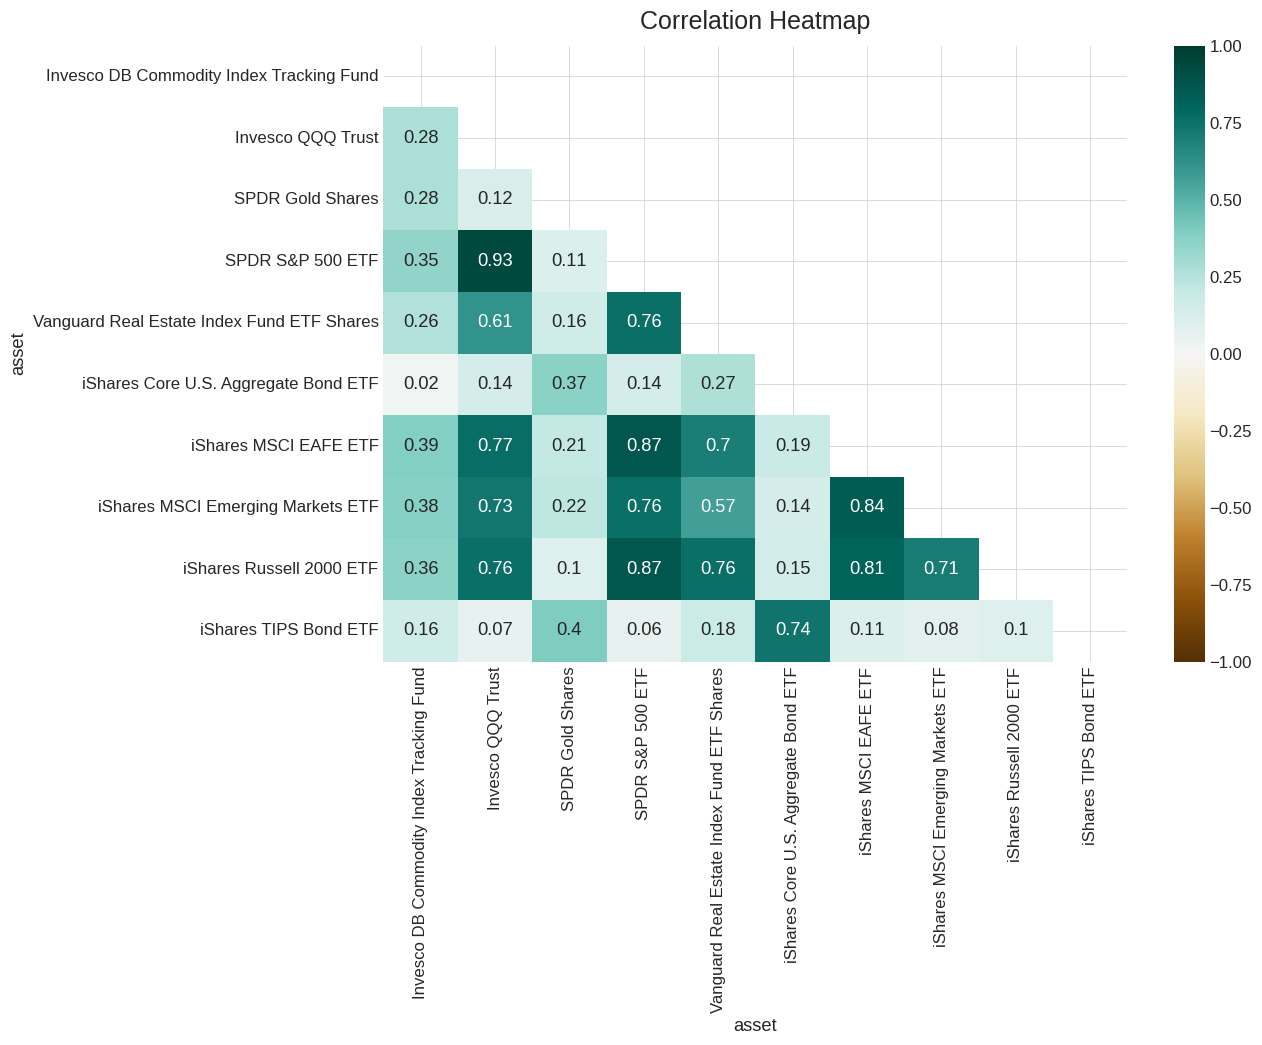

In [52]:
print("\n10.1 🔗 Correlation Matrix...")
correlation_matrix(
    returns_daily,
    corr_limit=None,
    figsize=(12, 8),
    diagonal=True
)
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


10.2 📅 Monthly Returns Heatmap...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


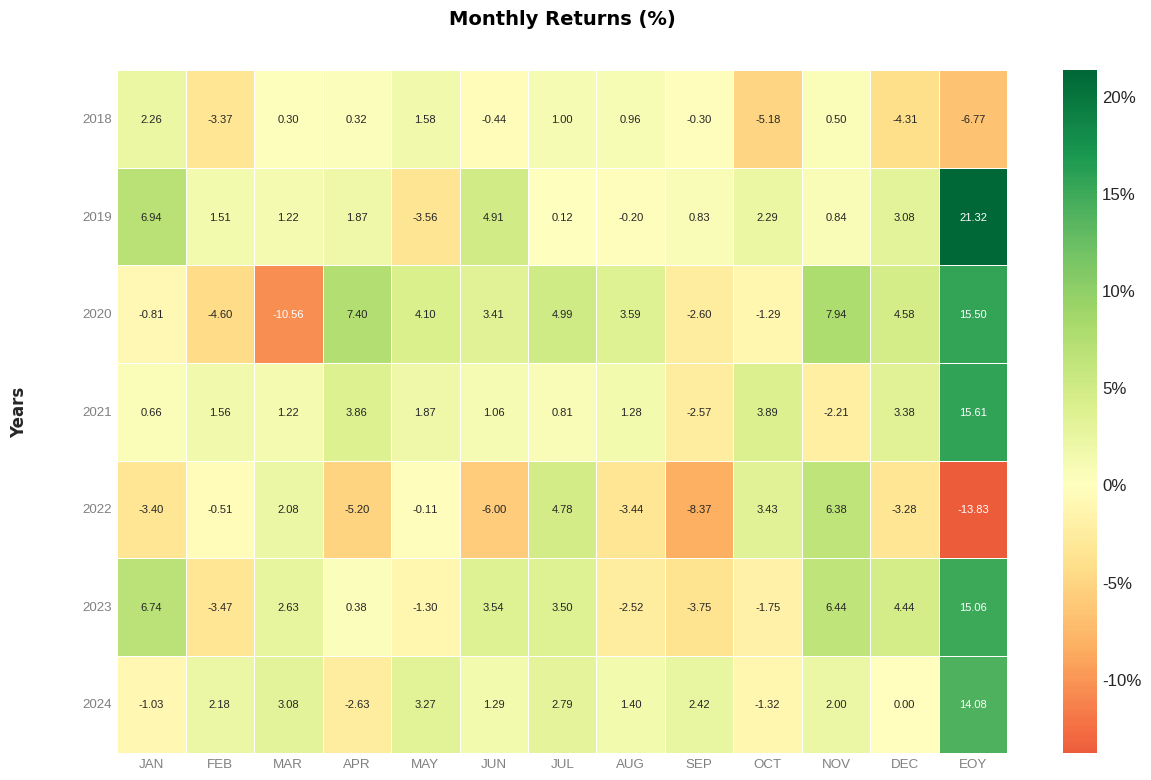

In [53]:
print("10.2 📅 Monthly Returns Heatmap...")
try:
    fig = monthly_heatmap(
        returns=portfolio_returns,
        annot_size=8,
        figsize=(12, 8),
        cbar=True,
        eoy=True,
        show=True
    )
except Exception as e:
    print(f"⚠️ Monthly heatmap: {e}")

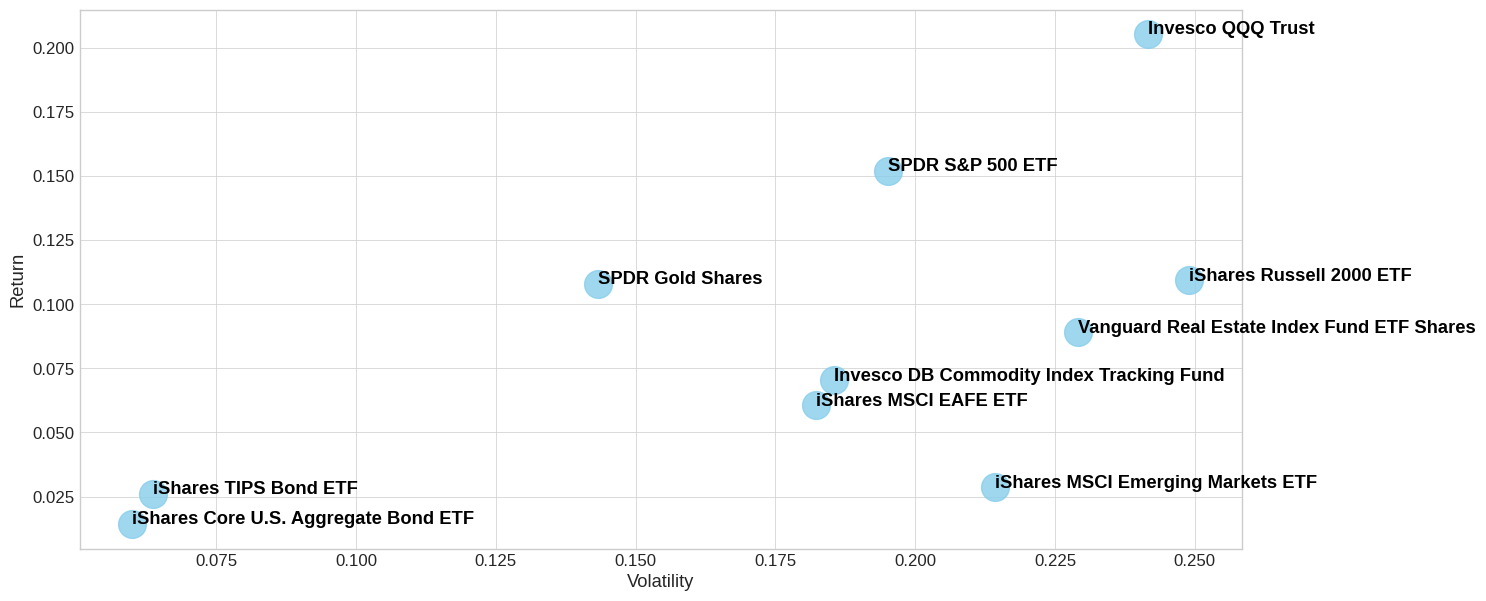

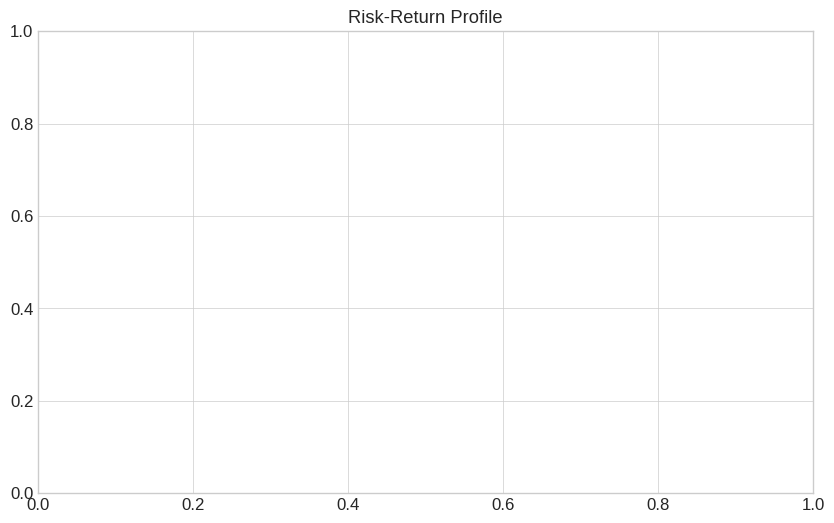

In [54]:
# Risk-Return Scatter Plot
risk_return = pd.DataFrame({
    'Return': returns_daily.mean() * 252,
    'Volatility': returns_daily.std() * np.sqrt(252)
})

scatter_plot_simple(risk_return, x='Volatility', y='Return')
plt.title('Risk-Return Profile')
plt.show()

10.3 📈 Portfolio Cumulative Returns Comparison...


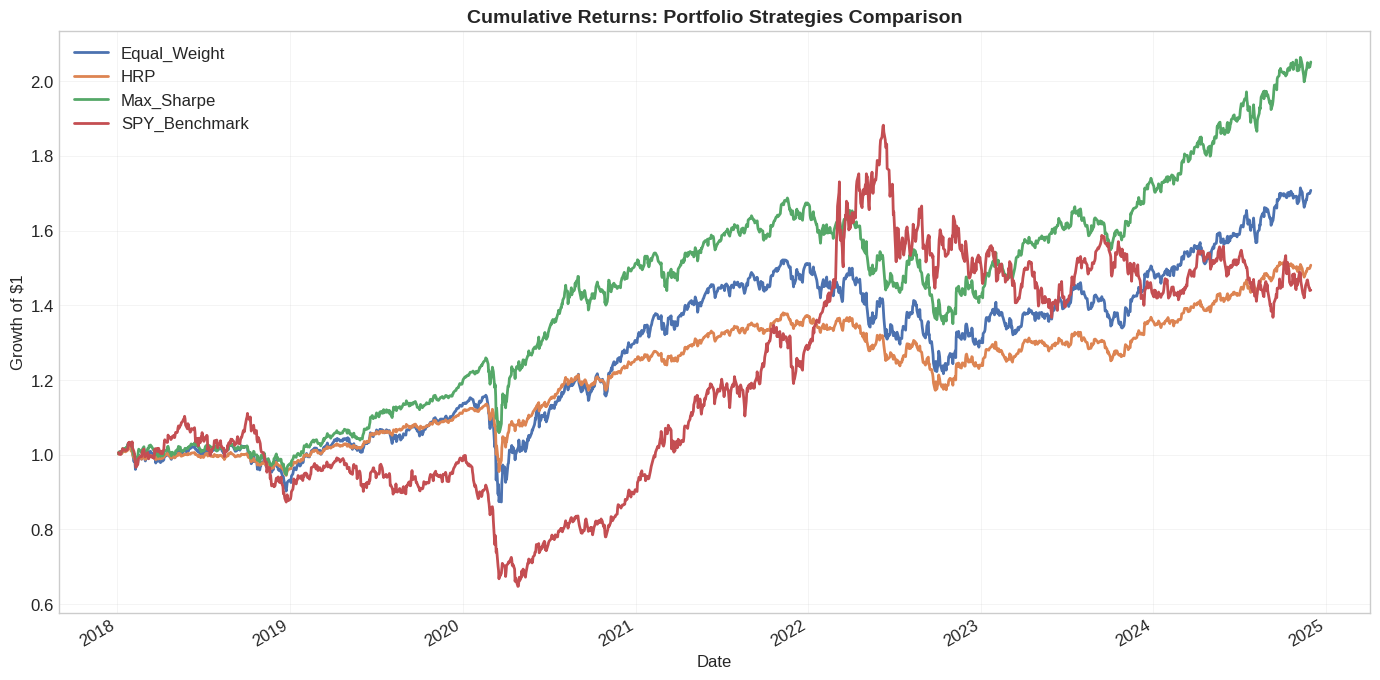


📋 Final Values (Growth of $1):


Equal_Weight    1.7082
HRP             1.5078
Max_Sharpe      2.0520
SPY_Benchmark   1.4410
Name: 2024-11-29 00:00:00, dtype: float64


✅ Visualization complete!


In [55]:
print("10.3 📈 Portfolio Cumulative Returns Comparison...")

# Calculate returns for different strategies
portfolio_comparison = pd.DataFrame({
    'Equal_Weight': (returns_daily * pd.Series(weights_equal['port_naive'].to_dict())).sum(axis=1),
    'HRP': (returns_daily * pd.Series(weights_hrp['port_weight'].to_dict())).sum(axis=1),
    'Max_Sharpe': (returns_daily * pd.Series(weights_max_sharpe['port_max_Sharpe'].to_dict())).sum(axis=1),  # Fixed: removed .set_index('asset')
    'SPY_Benchmark': returns_daily.iloc[:, 0]
})

# Cumulative returns
cum_returns = (1 + portfolio_comparison).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
cum_returns.plot(ax=ax, linewidth=2)
ax.set_title('Cumulative Returns: Portfolio Strategies Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Growth of $1', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Final Values (Growth of $1):")
display(cum_returns.iloc[-1].round(4))
print("\n✅ Visualization complete!")

---
## <a id="section11"></a>🎲 Section 11: Portfolio Selection (myPortfolioSelection.py)

Generate all possible portfolio combinations.

In [56]:
from myPortfolioManagement.myPortfolioSelection import (
    possible_combinations,
    all_combinations_inner_loop
)

print("="*80)
print("SECTION 11: PORTFOLIO SELECTION")
print("="*80)

SECTION 11: PORTFOLIO SELECTION


In [57]:
print("\n11.1 🎲 Generating all possible portfolio combinations...")
assets = ['SPY', 'QQQ', 'IWM', 'AGG', 'GLD']

# All combinations of 2-4 assets
combinations = possible_combinations(
    assets_to_consider=assets,
    min_assets=2,
    max_assets=4
)
print(f"\n✅ Number of possible portfolios (2-4 assets): {len(combinations)}")
print("\nFirst 10 combinations:")
for i, combo in enumerate(combinations[:10]):
    print(f"  {i+1}. {combo}")


11.1 🎲 Generating all possible portfolio combinations...
possible_combinations took 0.034ms

✅ Number of possible portfolios (2-4 assets): 25

First 10 combinations:
  1. ['SPY', 'QQQ']
  2. ['SPY', 'IWM']
  3. ['SPY', 'AGG']
  4. ['SPY', 'GLD']
  5. ['QQQ', 'IWM']
  6. ['QQQ', 'AGG']
  7. ['QQQ', 'GLD']
  8. ['IWM', 'AGG']
  9. ['IWM', 'GLD']
  10. ['AGG', 'GLD']


In [58]:
print("11.2 🎯 Combinations with must-have assets...")
combinations_must_have = possible_combinations(
    assets_to_consider=assets,
    min_assets=3,
    max_assets=4,
    must_have=['SPY', 'AGG']  # Must include these
)
print(f"\n✅ Portfolios that must include SPY and AGG: {len(combinations_must_have)}")
for combo in combinations_must_have:
    print(f"  {combo}")

print("\n✅ Portfolio selection complete!")

11.2 🎯 Combinations with must-have assets...
possible_combinations took 0.049ms

✅ Portfolios that must include SPY and AGG: 6
  ['SPY', 'QQQ', 'AGG']
  ['SPY', 'IWM', 'AGG']
  ['SPY', 'AGG', 'GLD']
  ['SPY', 'QQQ', 'IWM', 'AGG']
  ['SPY', 'QQQ', 'AGG', 'GLD']
  ['SPY', 'IWM', 'AGG', 'GLD']

✅ Portfolio selection complete!


---
## <a id="section12"></a>🎯 Section 12: Complete Workflow - End to End Example

This section demonstrates a complete portfolio management workflow:
1. Fetch data
2. Calculate returns
3. Optimize portfolio
4. Backtest strategy
5. Analyze performance

In [59]:
print("="*80)
print("SECTION 12: COMPLETE WORKFLOW - END TO END EXAMPLE")
print("="*80)

# Step 1: Data already fetched above
print("\n✅ Step 1: Using previously fetched data...")
print(f"  Assets: {list(prices.columns)}")
print(f"  Period: {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}")

SECTION 12: COMPLETE WORKFLOW - END TO END EXAMPLE

✅ Step 1: Using previously fetched data...
  Assets: ['Invesco DB Commodity Index Tracking Fund', 'Invesco QQQ Trust', 'SPDR Gold Shares', 'SPDR S&P 500 ETF', 'Vanguard Real Estate Index Fund ETF Shares', 'iShares Core U.S. Aggregate Bond ETF', 'iShares MSCI EAFE ETF', 'iShares MSCI Emerging Markets ETF', 'iShares Russell 2000 ETF', 'iShares TIPS Bond ETF']
  Period: 2018-01-02 to 2024-11-29


In [60]:
# Step 2: Split into training and testing
split_date = '2023-01-01'
returns_train = returns_daily[returns_daily.index < split_date]
returns_test = returns_daily[returns_daily.index >= split_date]
print(f"\n✅ Step 2: Train/Test Split at {split_date}")
print(f"  Training: {len(returns_train)} days")
print(f"  Testing: {len(returns_test)} days")


✅ Step 2: Train/Test Split at 2023-01-01
  Training: 1258 days
  Testing: 481 days


In [61]:
# Step 3: Optimize portfolios on training data
print("\n✅ Step 3: Optimizing portfolios on training data...")
weights_hrp_train = HRP(
    model='HRP',
    returns_training=returns_train.fillna(0),
    weight_max=0.25,
    weight_min=0.02
)
print("  HRP weights optimized")

weights_equal_train = equal_weight_portfolio(returns_train)
print("  Equal weight portfolio created")


✅ Step 3: Optimizing portfolios on training data...
  HRP weights optimized
  Equal weight portfolio created


In [62]:
# Step 4: Calculate out-of-sample returns
print("\n✅ Step 4: Calculating out-of-sample returns...")

# HRP portfolio returns
hrp_weights_dict = weights_hrp_train['port_weight'].to_dict()
portfolio_hrp_test = (returns_test * pd.Series(hrp_weights_dict)).sum(axis=1)
portfolio_hrp_test.name = 'HRP'

# Equal weight returns
equal_weights_dict = weights_equal_train['port_naive'].to_dict()
portfolio_equal_test = (returns_test * pd.Series(equal_weights_dict)).sum(axis=1)
portfolio_equal_test.name = 'Equal_Weight'

# Combine for comparison
portfolio_comparison = pd.DataFrame({
    'HRP': portfolio_hrp_test,
    'Equal_Weight': portfolio_equal_test,
    'SPY_Benchmark': returns_test.iloc[:, 0]  # SPY as benchmark
})


✅ Step 4: Calculating out-of-sample returns...


In [63]:
# Step 5: Performance analysis
print("\n✅ Step 5: Out-of-Sample Performance Analysis...")
test_stats = get_main_stats(portfolio_comparison, rf=0.04)
print("\n📋 Out-of-Sample Performance Metrics:")
display(test_stats.round(4))

# Cumulative returns
cum_returns = (1 + portfolio_comparison).cumprod()
print("\n📋 Cumulative Returns (End of Period):")
display(cum_returns.iloc[-1].round(4))


✅ Step 5: Out-of-Sample Performance Analysis...
get_main_stats took 110.54ms

📋 Out-of-Sample Performance Metrics:


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
HRP,0.2352,0.1172,1.5565,1.4692,1.9355,-0.0606
Equal_Weight,0.3126,0.1534,1.5725,1.4899,1.8440,-0.0832
SPY_Benchmark,-0.0577,-0.0307,-0.3564,-0.3700,-0.2221,-0.1382



📋 Cumulative Returns (End of Period):


HRP             1.2352
Equal_Weight    1.3126
SPY_Benchmark   0.9423
Name: 2024-11-29 00:00:00, dtype: float64

---
## 📊 Final Summary

Comprehensive analysis summary and key findings.

In [64]:
print("\n" + "="*80)
print("SUMMARY & KEY FINDINGS")
print("="*80)

print(f"""
🎉 Portfolio Management Analysis Complete!

📊 DATA ANALYZED:
- Assets: {len(tickers)} ETFs across multiple asset classes
- Period: {prices.index[0].strftime('%Y-%m-%d')} to {prices.index[-1].strftime('%Y-%m-%d')}
- Trading Days: {len(prices)}

🎯 OPTIMIZATION STRATEGIES TESTED:
- Equal Weight (Naive 1/N)
- Inverse Volatility
- Hierarchical Risk Parity (HRP)
- Hierarchical Equal Risk Contribution (HERC)
- Global Minimum Variance (GMV)
- Maximum Sharpe Ratio
- Minimum CVaR

📈 BEST PERFORMING ASSET:
- Ticker: {cagr_values.idxmax()}
- CAGR: {cagr_values.max():.2%}

📉 WORST PERFORMING ASSET:
- Ticker: {cagr_values.idxmin()}
- CAGR: {cagr_values.min():.2%}

💡 NEXT STEPS:
1. Review portfolio weights and adjust constraints
2. Run more extensive backtests with different parameters
3. Implement rebalancing strategy
4. Add transaction costs and slippage
5. Consider regime-based allocation

✅ All sections completed successfully!
""")

print("="*80)
print("END OF TUTORIAL")
print("="*80)


SUMMARY & KEY FINDINGS

🎉 Portfolio Management Analysis Complete!

📊 DATA ANALYZED:
- Assets: 10 ETFs across multiple asset classes
- Period: 2018-01-02 to 2024-11-29
- Trading Days: 1740

🎯 OPTIMIZATION STRATEGIES TESTED:
- Equal Weight (Naive 1/N)
- Inverse Volatility
- Hierarchical Risk Parity (HRP)
- Hierarchical Equal Risk Contribution (HERC)
- Global Minimum Variance (GMV)
- Maximum Sharpe Ratio
- Minimum CVaR

📈 BEST PERFORMING ASSET:
- Ticker: Invesco QQQ Trust
- CAGR: 19.21%

📉 WORST PERFORMING ASSET:
- Ticker: iShares MSCI Emerging Markets ETF
- CAGR: 0.55%

💡 NEXT STEPS:
1. Review portfolio weights and adjust constraints
2. Run more extensive backtests with different parameters
3. Implement rebalancing strategy
4. Add transaction costs and slippage
5. Consider regime-based allocation

✅ All sections completed successfully!

END OF TUTORIAL


---
## 📚 Additional Resources

**Documentation:**
- [GitHub Repository](https://github.com/ferhat00/QuantitativePortfolioManagement)
- [Riskfolio-Lib Docs](https://riskfolio-lib.readthedocs.io/)
- [PyPortfolioOpt Docs](https://pyportfolioopt.readthedocs.io/)

**Further Reading:**
- Hierarchical Risk Parity (López de Prado, 2016)
- Modern Portfolio Theory (Markowitz, 1952)
- Risk-based and Factor Investing (Ang, 2014)

**Key Concepts Demonstrated:**
1. ✅ Data fetching and preprocessing
2. ✅ Returns calculation (simple, log, different frequencies)
3. ✅ Portfolio optimization (7+ methods)
4. ✅ Performance metrics and risk analysis
5. ✅ Backtesting and Monte Carlo simulation
6. ✅ Asset clustering and regime detection
7. ✅ Comprehensive visualization
8. ✅ Complete end-to-end workflow

---
*Created with ❤️ for quantitative portfolio management*

*Compatible with Kaggle and Google Colab*